# Project 1 — Forecast Accuracy Improvement Engine

**Main question:** How good is our demand signal, and how can we improve it?

**System flow:** `[Project 1] → Safety Stock → Reorder Point → Fill Rate → Monetization → ROI`

---

## Sections
1. Load and inspect data
2. Compute error metrics per SKU-location
3. Bias analysis
4. SKU segmentation by forecastability
5. Error dashboard
6. Forecast Value Added (FVA)
7. Business summary and recommendations

In [1]:
import sys
from pathlib import Path

# Make src/ importable from the notebook
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from src.forecasting import (
    rmse, mae, bias, wape, mape, error_summary,
    naive_forecast, moving_average, exponential_smoothing,
)

sns.set_theme(style="whitegrid", palette="muted")
pd.set_option("display.float_format", "{:.2f}".format)
pd.set_option("display.max_columns", 30)

# Use processed (real) data if available, else fall back to sample (synthetic)
_processed = ROOT / "data" / "processed" / "master_data.csv"
_sample    = ROOT / "data" / "sample"    / "master_data.csv"
DATA = _processed if _processed.exists() else _sample
print(f"Data source: {DATA.relative_to(ROOT)}")
OUT  = ROOT / "outputs"
FIG  = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)

print("Root:", ROOT)

Data source: data\processed\master_data.csv
Root: C:\Users\simba\OneDrive\Dokumenter\Dev\supply-chain-uncertainty-system


---
## 1. Load and inspect data

In [2]:
df = pd.read_csv(DATA, parse_dates=["date"])
print(f"{len(df):,} rows | {df['sku'].nunique()} SKUs | {df['location'].nunique()} locations")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
df.head(3)

46,800 rows | 60 SKUs | 5 locations


Date range: 2022-01-03 to 2024-12-23


,sku,location,date,actual_demand,forecast,abc_class,xyz_class,cv,promo_flag,holiday_flag,lead_time_mean,lead_time_std,unit_cost,unit_margin,holding_cost_rate,shortage_cost_per_unit,service_target,safety_stock,reorder_point,on_hand,on_order,stockout_flag,product_family
0,SKU_A01,Store_Central,2022-01-03,193,206,A,X,0.36,0,1,5,1,1.25,0.38,0.20,0.57,0.95,111.00,301.00,97.00,11.00,1,DAIRY
1,SKU_A01,Store_Central,2022-01-10,207,203,A,X,0.36,0,1,5,1,1.25,0.38,0.20,0.57,0.95,111.00,301.00,264.00,62.00,0,DAIRY
2,SKU_A01,Store_Central,2022-01-17,246,199,A,X,0.36,0,0,5,1,1.25,0.38,0.20,0.57,0.95,111.00,301.00,131.00,53.00,1,DAIRY


In [3]:
# Exclude promo and holiday weeks from baseline error measurement
df_clean = df[(df["promo_flag"] == 0) & (df["holiday_flag"] == 0)].copy()
print(f"{len(df_clean):,} rows after removing promo/holiday weeks")

36,045 rows after removing promo/holiday weeks


---
## 2. Error metrics per SKU-location

In [4]:
def sku_errors(grp: pd.DataFrame) -> pd.Series:
    a = grp["actual_demand"].values
    f = grp["forecast"].values
    mask = a > 0  # exclude zero-demand weeks from MAPE/WAPE
    return pd.Series({
        "weeks":     len(a),
        "avg_demand": a.mean(),
        "rmse":      rmse(a, f),
        "mae":       mae(a, f),
        "bias":      bias(a, f),
        "wape":      wape(a[mask], f[mask]),
        "mape":      mape(a[mask], f[mask]),
        "abc_class": grp["abc_class"].iloc[0],
        "xyz_class": grp["xyz_class"].iloc[0],
        "cv":        grp["cv"].iloc[0],
    })

errors = (
    df_clean
    .groupby(["sku", "location"])
    .apply(sku_errors, include_groups=False)
    .reset_index()
)

errors["bias_pct"] = errors["bias"] / errors["avg_demand"]
errors["segment"]  = errors["abc_class"] + "/" + errors["xyz_class"]

print(f"{len(errors)} SKU-location combinations")
errors.sort_values("wape", ascending=False).head(10)

300 SKU-location combinations


,sku,location,weeks,avg_demand,rmse,mae,bias,wape,mape,abc_class,xyz_class,cv,bias_pct,segment
257,SKU_C17,Store_North,117,4.62,8.44,6.04,-2.40,0.97,2.23,C,Z,1.37,-0.52,C/Z
273,SKU_C20,Store_South,120,2.92,4.93,3.83,-0.94,0.96,1.79,C,Z,1.40,-0.32,C/Z
249,SKU_C15,Store_West,123,3.85,6.13,4.41,-0.61,0.94,1.74,C,Z,1.30,-0.16,C/Z
285,SKU_C23,Store_Central,117,8.38,13.16,8.63,0.14,0.94,2.42,C,Z,1.40,0.02,C/Z
240,SKU_C14,Store_Central,120,8.60,11.83,8.93,-0.47,0.91,2.68,B,Z,1.22,-0.05,B/Z
255,SKU_C17,Store_Central,117,6.81,8.75,6.87,-0.50,0.90,2.49,C,Z,1.37,-0.07,C/Z
195,SKU_C05,Store_Central,117,17.66,21.22,15.89,-2.04,0.89,2.40,B,Z,1.04,-0.12,B/Z
235,SKU_C13,Store_Central,120,7.64,9.98,7.89,-2.04,0.89,2.55,B,Z,1.22,-0.27,B/Z
252,SKU_C16,Store_North,117,8.81,14.58,9.40,0.10,0.89,2.03,B,Z,1.28,0.01,B/Z
227,SKU_C11,Store_North,123,9.46,12.40,9.46,-1.45,0.89,2.20,C,Z,1.08,-0.15,C/Z


In [5]:
# Summary statistics by ABC class
errors.groupby("abc_class")[["rmse", "mae", "wape", "bias_pct"]].mean().round(3)

,rmse,mae,wape,bias_pct
abc_class,,,,
A,25.64,20.27,0.32,-0.01
B,13.74,10.48,0.65,0.01
C,6.43,4.69,0.79,-0.04


---
## 3. Bias analysis

**Positive bias** = we under-forecast (actual > forecast) → risk of stockout

**Negative bias** = we over-forecast (forecast > actual) → risk of excess inventory

In [6]:
errors["bias_direction"] = errors["bias_pct"].apply(
    lambda x: "Under-forecast" if x > 0.05 else ("Over-forecast" if x < -0.05 else "Neutral")
)

print("Bias distribution:")
print(errors["bias_direction"].value_counts())
print()
print("By ABC class:")
print(errors.groupby(["abc_class", "bias_direction"]).size().unstack(fill_value=0))

Bias distribution:
bias_direction
Neutral           139
Over-forecast      84
Under-forecast     77
Name: count, dtype: int64

By ABC class:
bias_direction  Neutral  Over-forecast  Under-forecast
abc_class                                             
A                    95             39              31
B                    28             20              32
C                    16             25              14


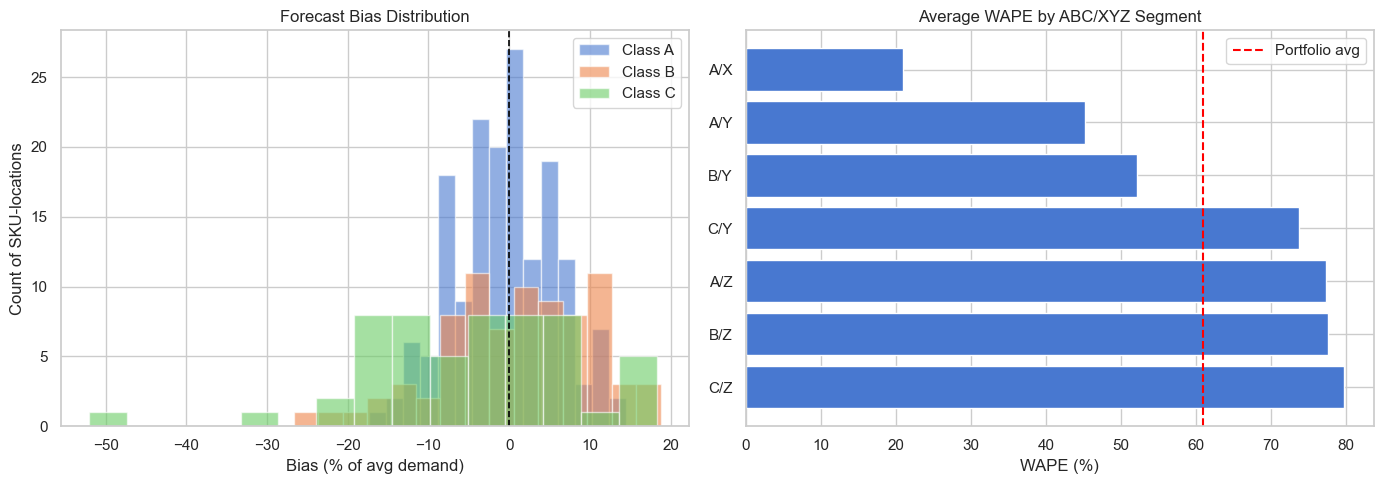

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bias distribution
axes[0].axvline(0, color="black", linewidth=1.2, linestyle="--")
for abc, grp in errors.groupby("abc_class"):
    axes[0].hist(grp["bias_pct"] * 100, bins=15, alpha=0.6, label=f"Class {abc}")
axes[0].set_xlabel("Bias (% of avg demand)")
axes[0].set_ylabel("Count of SKU-locations")
axes[0].set_title("Forecast Bias Distribution")
axes[0].legend()

# WAPE by segment
seg_wape = errors.groupby("segment")["wape"].mean().sort_values(ascending=False)
axes[1].barh(seg_wape.index, seg_wape.values * 100)
axes[1].set_xlabel("WAPE (%)")
axes[1].set_title("Average WAPE by ABC/XYZ Segment")
axes[1].axvline(seg_wape.mean() * 100, color="red", linestyle="--", label="Portfolio avg")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG / "01a_bias_and_wape.png", dpi=150)
plt.show()

---
## 4. SKU segmentation by forecastability

In [8]:
def forecastability(wape: float) -> str:
    if wape <= 0.20:
        return "High"
    elif wape <= 0.40:
        return "Medium"
    return "Low"

errors["forecastability"] = errors["wape"].apply(forecastability)

print("Forecastability breakdown:")
print(errors.groupby(["abc_class", "forecastability"]).size().unstack(fill_value=0))

Forecastability breakdown:
forecastability  High  Low  Medium
abc_class                         
A                  55   39      71
B                   0   76       4
C                   0   55       0


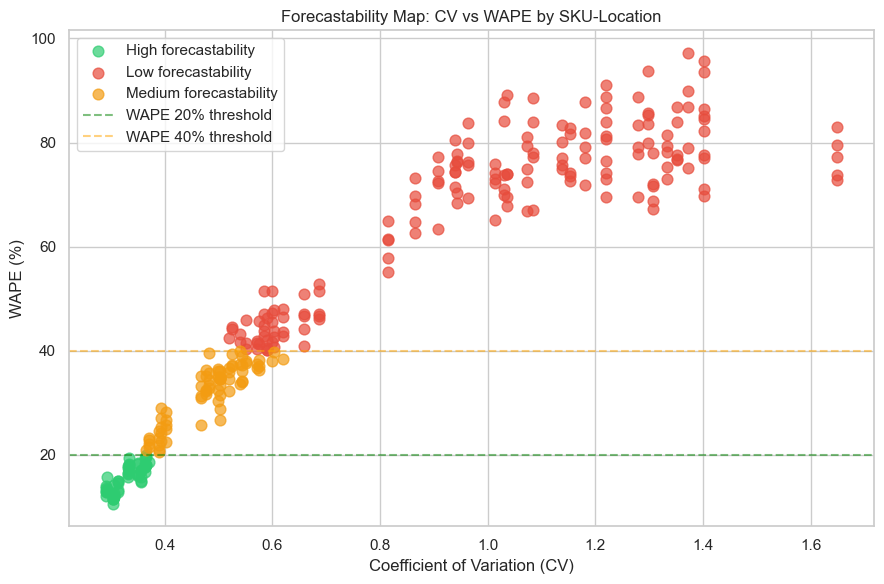

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))

colors = {"High": "#2ecc71", "Medium": "#f39c12", "Low": "#e74c3c"}
for fc, grp in errors.groupby("forecastability"):
    ax.scatter(
        grp["cv"], grp["wape"] * 100,
        label=f"{fc} forecastability",
        color=colors[fc], alpha=0.7, s=60,
    )

ax.axhline(20, color="green",  linestyle="--", alpha=0.5, label="WAPE 20% threshold")
ax.axhline(40, color="orange", linestyle="--", alpha=0.5, label="WAPE 40% threshold")
ax.set_xlabel("Coefficient of Variation (CV)")
ax.set_ylabel("WAPE (%)")
ax.set_title("Forecastability Map: CV vs WAPE by SKU-Location")
ax.legend()
plt.tight_layout()
plt.savefig(FIG / "01b_forecastability_map.png", dpi=150)
plt.show()

---
## 5. Error dashboard — worst SKUs

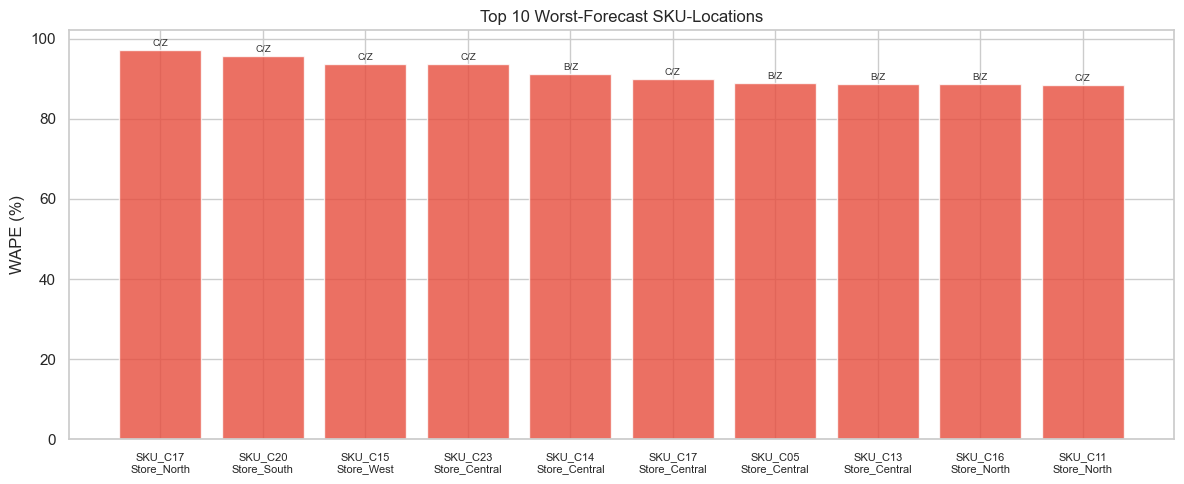

In [10]:
# Top 10 SKU-locations by WAPE
worst = errors.sort_values("wape", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
labels = worst["sku"] + "\n" + worst["location"]
bars = ax.bar(range(len(worst)), worst["wape"] * 100, color="#e74c3c", alpha=0.8)
ax.set_xticks(range(len(worst)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("WAPE (%)")
ax.set_title("Top 10 Worst-Forecast SKU-Locations")

for bar, (_, row) in zip(bars, worst.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        row["abc_class"] + "/" + row["xyz_class"],
        ha="center", va="bottom", fontsize=7, color="#333",
    )

plt.tight_layout()
plt.savefig(FIG / "01c_worst_skus.png", dpi=150)
plt.show()

In [11]:
# Cumulative WAPE contribution: which SKUs drive most error?
errors_sorted = errors.sort_values("rmse", ascending=False).copy()
errors_sorted["cum_rmse_pct"] = errors_sorted["rmse"].cumsum() / errors_sorted["rmse"].sum()
n80 = (errors_sorted["cum_rmse_pct"] <= 0.80).sum()
print(f"{n80} SKU-locations ({n80/len(errors)*100:.0f}%) account for 80% of total RMSE")

167 SKU-locations (56%) account for 80% of total RMSE


---
## 6. Forecast Value Added (FVA)

Compare the existing forecast against a naive benchmark (lag-1 actual).

- FVA > 0 → the forecast adds value over naive
- FVA < 0 → the naive forecast is better; the forecast is destroying value

In [12]:
def compute_fva(grp: pd.DataFrame) -> pd.Series:
    grp = grp.sort_values("date")
    actual = grp["actual_demand"].values
    forecast = grp["forecast"].values
    naive = np.roll(actual, 1)  # lag-1
    naive[0] = actual[0]

    mae_fc = mae(actual, forecast)
    mae_naive = mae(actual, naive)
    fva = (mae_naive - mae_fc) / mae_naive if mae_naive > 0 else 0

    return pd.Series({
        "mae_forecast": mae_fc,
        "mae_naive":    mae_naive,
        "fva":          fva,
        "abc_class":    grp["abc_class"].iloc[0],
    })

fva_df = (
    df_clean
    .groupby(["sku", "location"])
    .apply(compute_fva, include_groups=False)
    .reset_index()
)

print(f"FVA > 0 (forecast beats naive): {(fva_df['fva'] > 0).sum()} SKU-locations")
print(f"FVA < 0 (naive beats forecast): {(fva_df['fva'] < 0).sum()} SKU-locations")
print()
fva_df.groupby("abc_class")["fva"].mean().round(3)

FVA > 0 (forecast beats naive): 297 SKU-locations
FVA < 0 (naive beats forecast): 3 SKU-locations



abc_class
A   0.20
B   0.17
C   0.13
Name: fva, dtype: float64

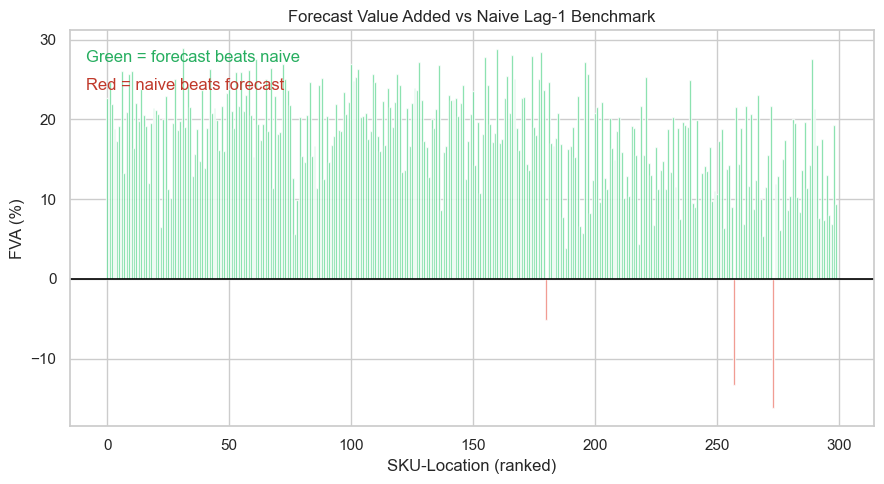

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = fva_df["fva"].apply(lambda x: "#2ecc71" if x > 0 else "#e74c3c")
ax.bar(range(len(fva_df)), fva_df["fva"] * 100, color=colors, alpha=0.8)
ax.axhline(0, color="black", linewidth=1.2)
ax.set_xlabel("SKU-Location (ranked)")
ax.set_ylabel("FVA (%)")
ax.set_title("Forecast Value Added vs Naive Lag-1 Benchmark")
ax.annotate("Green = forecast beats naive", xy=(0.02, 0.92), xycoords="axes fraction", color="#27ae60")
ax.annotate("Red = naive beats forecast",   xy=(0.02, 0.85), xycoords="axes fraction", color="#c0392b")
plt.tight_layout()
plt.savefig(FIG / "01d_fva.png", dpi=150)
plt.show()

---
## 7. Business summary and recommendations

In [14]:
# Build recommendation table
rec = errors.merge(
    fva_df[["sku", "location", "fva"]],
    on=["sku", "location"]
).copy()

def recommend(row) -> str:
    if row["fva"] < 0 and row["forecastability"] == "Low":
        return "Switch to naive / statistical model"
    elif row["forecastability"] == "Low" and row["abc_class"] == "A":
        return "Priority: improve model or add causal drivers"
    elif row["bias_direction"] == "Over-forecast" and row["abc_class"] in ["A", "B"]:
        return "Review and debias — excess inventory risk"
    elif row["bias_direction"] == "Under-forecast" and row["abc_class"] == "A":
        return "Review and debias — stockout risk"
    elif row["forecastability"] == "High":
        return "No action — forecast is performing well"
    return "Monitor"

rec["recommendation"] = rec.apply(recommend, axis=1)

print("Recommendation summary:")
print(rec["recommendation"].value_counts())

Recommendation summary:
recommendation
Monitor                                          152
No action — forecast is performing well           46
Review and debias — excess inventory risk         45
Priority: improve model or add causal drivers     38
Review and debias — stockout risk                 16
Switch to naive / statistical model                3
Name: count, dtype: int64


In [15]:
# Final output table
output_cols = [
    "sku", "location", "abc_class", "xyz_class",
    "avg_demand", "wape", "bias_pct", "fva",
    "forecastability", "bias_direction", "recommendation"
]
output = rec[output_cols].sort_values(["abc_class", "wape"], ascending=[True, False])
output.to_csv(OUT / "tables" / "01_forecast_accuracy_results.csv", index=False)
print("Saved results table.")
output.head(15)

Saved results table.


,sku,location,abc_class,xyz_class,avg_demand,wape,bias_pct,fva,forecastability,bias_direction,recommendation
208,SKU_C07,Store_South,A,Z,10.79,0.88,-0.12,0.15,Low,Over-forecast,Priority: improve model or add causal drivers
207,SKU_C07,Store_North,A,Z,13.27,0.84,-0.03,0.16,Low,Neutral,Priority: improve model or add causal drivers
203,SKU_C06,Store_South,A,Y,11.08,0.81,-0.03,0.22,Low,Neutral,Priority: improve model or add causal drivers
201,SKU_C06,Store_East,A,Y,9.38,0.76,0.08,0.22,Low,Under-forecast,Priority: improve model or add causal drivers
204,SKU_C06,Store_West,A,Y,9.75,0.74,0.12,0.13,Low,Under-forecast,Priority: improve model or add causal drivers
200,SKU_C06,Store_Central,A,Y,14.70,0.74,0.13,0.21,Low,Under-forecast,Priority: improve model or add causal drivers
209,SKU_C07,Store_West,A,Z,6.93,0.74,-0.04,0.19,Low,Neutral,Priority: improve model or add causal drivers
183,SKU_C02,Store_South,A,Y,15.41,0.73,0.11,0.17,Low,Under-forecast,Priority: improve model or add causal drivers
202,SKU_C06,Store_North,A,Y,13.40,0.72,-0.10,0.10,Low,Over-forecast,Priority: improve model or add causal drivers
205,SKU_C07,Store_Central,A,Z,15.66,0.71,-0.07,0.11,Low,Over-forecast,Priority: improve model or add causal drivers


In [16]:
# Portfolio-level KPI summary
print("===== FORECAST ACCURACY SUMMARY =====")
print(f"Portfolio avg WAPE:       {errors['wape'].mean()*100:.1f}%")
print(f"Portfolio avg Bias:       {errors['bias_pct'].mean()*100:.1f}%")
print(f"SKUs with FVA > 0:        {(fva_df['fva']>0).sum()} / {len(fva_df)}")
print(f"High forecastability:     {(errors['forecastability']=='High').sum()} SKU-locs")
print(f"Low forecastability:      {(errors['forecastability']=='Low').sum()} SKU-locs")
print(f"Bias: over-forecast:      {(errors['bias_direction']=='Over-forecast').sum()} SKU-locs")
print(f"Bias: under-forecast:     {(errors['bias_direction']=='Under-forecast').sum()} SKU-locs")
print()
print("These results feed directly into Project 2 (Safety Stock sizing).")
print("The forecast error (sigma_demand per SKU) is the key input.")

===== FORECAST ACCURACY SUMMARY =====
Portfolio avg WAPE:       49.6%
Portfolio avg Bias:       -0.8%
SKUs with FVA > 0:        297 / 300
High forecastability:     55 SKU-locs
Low forecastability:      170 SKU-locs
Bias: over-forecast:      84 SKU-locs
Bias: under-forecast:     77 SKU-locs

These results feed directly into Project 2 (Safety Stock sizing).
The forecast error (sigma_demand per SKU) is the key input.
